## Imbalanced Data

**You will observe a major difference in datapoint count related to target classes. This might introduce biased nature in model while predicting individual datapoints.**

    To overcome this, observe the imbalance percentage and decide what can be done:

    1) 15-20% : we can split our data on basis of stratified split and during model building, we can pass the parameter class='balanced'
    2) Below 15%: use resampling technique. 

**Resampling:**

    Over sampling: creates minority classes more in such a way that the count matches with majority classes
    Under sampling: Reduces majority classes more in such a way the count matches with minority classes
    Business Objective: Build a model that can predict the status of Loan Approval on basis of many intermediate factors.
    Data Gathering

In [1]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/train_loan.csv")
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### Preform basic data quality check

In [2]:
df.shape

(58645, 13)

In [3]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

### Separate X and Y Features

    Y : Loan Status

    0-> Not Approved
    1-> Approved

In [5]:
X = df.drop(columns=['id', 'loan_status'])
Y = df[['loan_status']]

display(X.head())
print("-----------------")
display(Y.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3


-----------------


,loan_status
0,0
1,0
2,0
3,0
4,0


### Observe whether Y data is balanced or not.

**Meaning: DO we have moderate datapoints for Class approved and Not approved(0,1)**

In [6]:
Y['loan_status'].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

In [7]:
((Y['loan_status'].value_counts())/(len(df)))*100

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64

<Axes: ylabel='loan_status'>

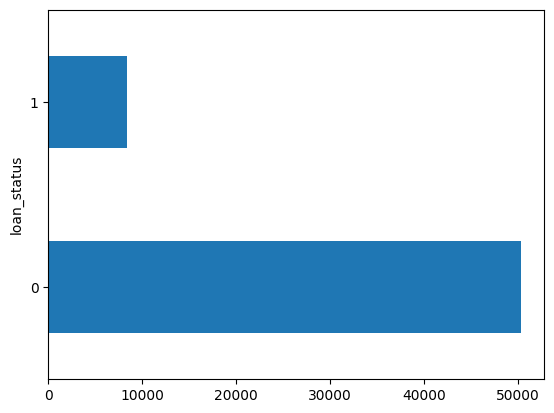

In [8]:
Y['loan_status'].value_counts().plot(kind='barh')

### The dataset is imbalanced in nature

### Technique 1: splitting the data on basis of stratified split

In [9]:
from sklearn.model_selection import train_test_split
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(X,Y,train_size=0.75,stratify=Y)


In [10]:
xtrain1.shape

(43983, 11)

In [11]:
ytrain1.shape

(43983, 1)

In [12]:
xtrain1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
36843,30,54000,MORTGAGE,5.0,DEBTCONSOLIDATION,B,10000,9.99,0.19,N,5
19248,22,60000,RENT,6.0,EDUCATION,B,12000,10.62,0.20,N,3
269,23,65000,RENT,2.0,EDUCATION,C,8000,12.68,0.12,N,3
54883,45,49800,MORTGAGE,13.0,HOMEIMPROVEMENT,A,2400,6.99,0.05,N,12
31611,23,33600,RENT,4.0,EDUCATION,C,5000,14.26,0.15,N,3


In [13]:
xtest1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
37767,23,50000,MORTGAGE,7.0,EDUCATION,A,6000,8.49,0.12,N,3
44069,28,80000,MORTGAGE,12.0,VENTURE,B,12000,11.71,0.15,N,7
33720,25,130000,MORTGAGE,10.0,MEDICAL,B,24250,12.53,0.19,N,2
30446,34,30000,MORTGAGE,5.0,MEDICAL,A,3000,7.51,0.10,N,6
43671,24,32640,MORTGAGE,8.0,HOMEIMPROVEMENT,A,3000,7.51,0.09,N,2


### Data Preprocessing and Data Cleaning

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns) 
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler())

cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore',sparse_output=False))

pre = ColumnTransformer([('cat',cat_pipe,cat),
                         ('con',num_pipe,con)]).set_output(transform='pandas')

pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [15]:
pre.fit(xtrain1)

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [16]:
xtrain1_pre = pre.transform(xtrain1)
xtest1_pre = pre.transform(xtest1)

In [17]:
xtrain1_pre.head(2)

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
36843,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.404422,-0.266494,0.078881,0.141594,-0.224705,0.335308,-0.201495
19248,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.918586,-0.104733,0.333202,0.500674,-0.016983,0.444301,-0.697512


### Model Building

In [18]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(class_weight='balanced')
model1.fit(xtrain1_pre,ytrain1)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
model1.score(xtrain1_pre,ytrain1)

0.8443716890616829

In [20]:
model1.score(xtest1_pre,ytest1)

0.8394489155640431

### Performance Metrics

In [21]:
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report

ypreds =   model1.predict(xtest1_pre)

f1_data = f1_score(ytest1,ypreds)
f1_data

0.5901810584958217

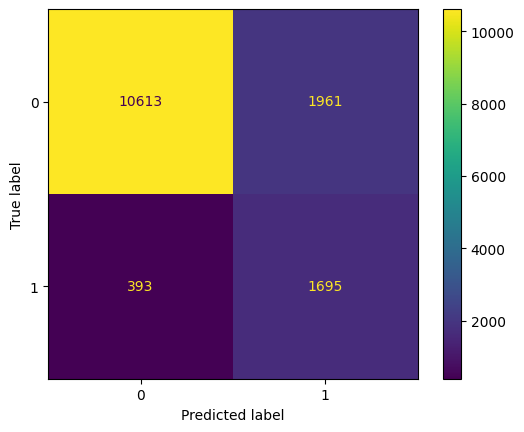

In [22]:
ConfusionMatrixDisplay.from_estimator(model1,xtest1_pre,ytest1)

In [23]:
print(classification_report(ytest1,ypreds))

              precision    recall  f1-score   support

           0       0.96      0.84      0.90     12574
           1       0.46      0.81      0.59      2088

    accuracy                           0.84     14662
   macro avg       0.71      0.83      0.75     14662
weighted avg       0.89      0.84      0.86     14662



### Technique3: Resampling Method

In [24]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


### Restart the kernel and run all the cells

Resampling:

1. Over sampling -> SMOTE , ADASYN SMOTE: Synthetic Minority Over sampling technique ADASYN : Adaptive Synthetic sample technique
2. Under sampling

In [25]:
len(xtest1_pre)

14662

In [26]:
ytrain1['loan_status'].value_counts()

loan_status
0    37721
1     6262
Name: count, dtype: int64

In [27]:
from imblearn.over_sampling import SMOTE,ADASYN

smote = SMOTE()

x_sampl,y_sampl = smote.fit_resample(xtrain1_pre,ytrain1)

In [28]:
len(x_sampl)

75442

In [29]:
len(y_sampl)

75442

In [30]:
y_sampl['loan_status'].value_counts()

loan_status
0    37721
1    37721
Name: count, dtype: int64

### Model Building using SMOTE sampling technique

In [32]:
model2 = LogisticRegression()
model2.fit(x_sampl,y_sampl)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
model2.score(x_sampl,y_sampl)

0.8418917844171682

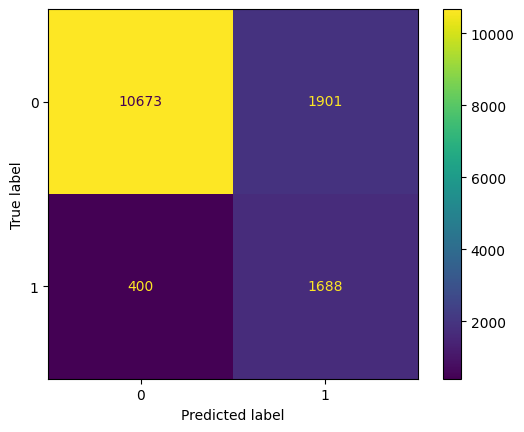

In [34]:
ConfusionMatrixDisplay.from_estimator(model2,xtest1_pre,ytest1)

In [35]:
ypred_sampl = model2.predict(xtest1_pre)
print(classification_report(ytest1,ypred_sampl))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     12574
           1       0.47      0.81      0.59      2088

    accuracy                           0.84     14662
   macro avg       0.72      0.83      0.75     14662
weighted avg       0.89      0.84      0.86     14662



In [36]:
ada = ADASYN()
x_sampl_ada,y_sampl_ada = ada.fit_resample(xtrain1_pre,ytrain1)
y_sampl_ada['loan_status'].value_counts()

loan_status
0    37721
1    37675
Name: count, dtype: int64

In [38]:
model3 = LogisticRegression()
model3.fit(x_sampl_ada,y_sampl_ada)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
model3.score(x_sampl_ada,y_sampl_ada)

0.7530638230144835

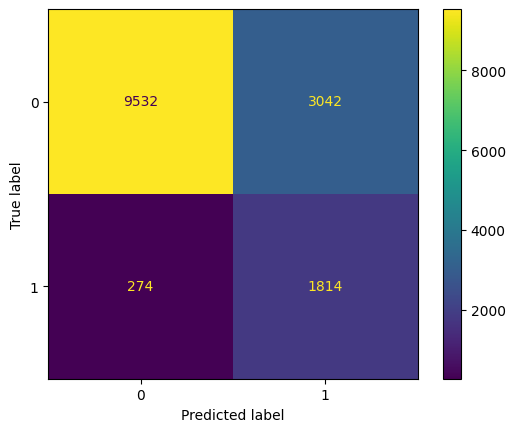

In [40]:
ConfusionMatrixDisplay.from_estimator(model3,xtest1_pre,ytest1)

In [41]:
ypreds_ada = model3.predict(xtest1_pre)
print(classification_report(ytest1,ypreds_ada))

              precision    recall  f1-score   support

           0       0.97      0.76      0.85     12574
           1       0.37      0.87      0.52      2088

    accuracy                           0.77     14662
   macro avg       0.67      0.81      0.69     14662
weighted avg       0.89      0.77      0.80     14662



### Logistic regression generates results in probabilities

    Default threshold: 0.5
    Category the data into classes on basis of the above threshold. (>0.5: Class A, <0.5: Class B>)

In [43]:
probs = model3.predict_proba(xtest1_pre)
print(probs[:5])
print(ypreds_ada[:5])


[[0.82473316 0.17526684]
 [0.86676197 0.13323803]
 [0.81993486 0.18006514]
 [0.75403772 0.24596228]
 [0.67864975 0.32135025]]
[0 0 0 0 0]


### ROC Metric: ROC Curve

        Receiver Operator Characterstic

        Analysis: If the Area under curve(AUC) is more than 0.80(80%), the model is resulting in accurate predictions

In [45]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
ypred = model2.predict_proba(xtest1_pre)[:,1] # probabilities for positive class 
fpr,tpr,thresholds = roc_curve(ytest1,ypred_sampl)
roc_auc_score = auc(fpr,tpr) # Main auc for each model
print(roc_auc_score)

0.8286220669422459


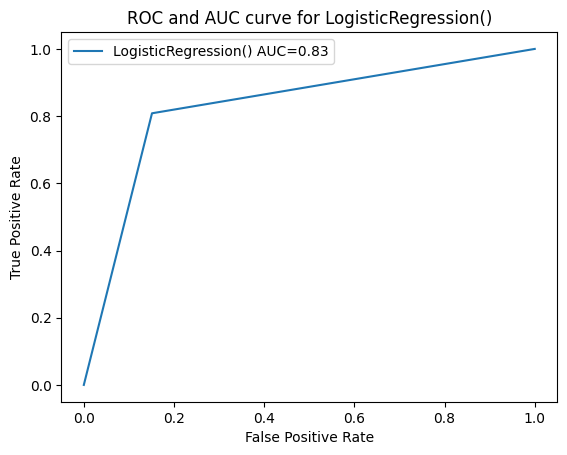

In [47]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
ypred = model2.predict_proba(xtest1_pre)[:,1]
fpr,tpr,thresholds = roc_curve(ytest1,ypred_sampl)
roc_auc_score = auc(fpr,tpr)
# # auc_scores = roc_auc_score
plt.plot (fpr,tpr,label=f'{model2} AUC={roc_auc_score:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC and AUC curve for {model2}')
plt.legend()
plt.show()

### We can finalise model2 created using SMOTE technique for Deployment.

### Save the pipeline and finalised model

In [48]:
import joblib
joblib.dump(model2,"Model_SMOTE.joblib")
joblib.dump(pre,"Preprocessor.joblib")


['Preprocessor.joblib']

### Out of sample predictions

In [49]:
xnew = pd.read_csv(r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/test_loan.csv")
xnew.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


### Load the saved preprocessor and model

In [50]:
pre_loaded = joblib.load("Preprocessor.joblib")
model_loaded =  joblib.load("Model_SMOTE.joblib")


In [52]:
xnew_pre = pre_loaded.transform(xnew)
xnew_pre.head()

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.753210,0.137908,-0.429760,2.834695,1.677767,2.188196,-0.945521
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,-0.257082,0.865833,0.333202,0.141594,0.662236,-0.645633,-0.449503
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,-0.257082,-0.913538,0.078881,-0.935647,2.149264,-0.318652,-0.945521
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.900550,-0.374335,-0.175439,-0.397026,-0.584098,-0.209659,0.294523
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.257082,1.027594,0.841843,1.039294,1.862409,-0.100666,-0.449503


In [53]:
final_preds = model_loaded.predict(xnew_pre)
final_preds[:10]

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [54]:
xnew['Loan Status Approval Prediction'] = final_preds
xnew.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Loan Status Approval Prediction
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2,1
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4,0
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2,1
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7,0
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4,1


In [55]:
xnew.to_csv("Predicted results.csv",index=False)


### Random Under Sampler --> use it only for Large datasets

In [56]:
from imblearn.under_sampling import RandomUnderSampler
rand = RandomUnderSampler()
x_sampl_under,y_sampl_under = rand.fit_resample(xtrain1_pre,ytrain1)
y_sampl_under['loan_status'].value_counts()

loan_status
0    6262
1    6262
Name: count, dtype: int64

In [58]:
model4 = LogisticRegression()
model4.fit(x_sampl_under,y_sampl_under)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
model4.score(x_sampl_under,y_sampl_under)

0.8339987224528904

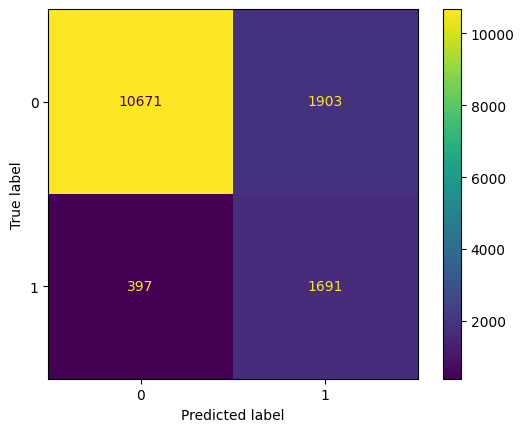

In [60]:
ConfusionMatrixDisplay.from_estimator(model4, xtest1_pre,ytest1)

In [61]:
ypred_under= model4.predict(xtest1_pre)
print(classification_report(ytest1,ypred_under))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     12574
           1       0.47      0.81      0.60      2088

    accuracy                           0.84     14662
   macro avg       0.72      0.83      0.75     14662
weighted avg       0.89      0.84      0.86     14662



In [62]:
fpr1,tpr1,thresholds = roc_curve(ytest1,ypred_under)

roc_auc_score2 = auc(fpr1,tpr1)
print(roc_auc_score2)

0.829260928559632


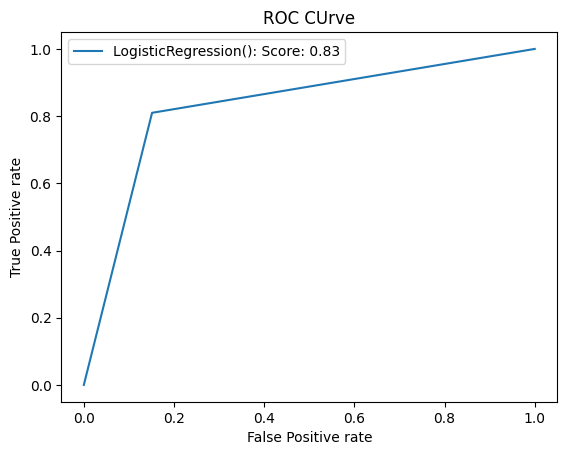

In [63]:
plt.plot(fpr1,tpr1,label=f"{model4}: Score: {roc_auc_score2:.2f}")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.title("ROC CUrve")
plt.legend()
plt.show()